# 루프 워크플로 구현 : 숫자 맞추기 

In [ ]:
# 랭그래프에서는 순환하는 그래프 구조도 만들 수 있습니다
# 조건이 만족할 때까지 루프를 실행하는 루프 워크플로를 손쉽게 작성할 수 있습니다
# 루프 패턴은 대화형 애플리케이션, 재시도 로직, 반복 작업 등에 활용할 수 있는 중요한 패턴

# import

In [1]:
from dotenv import load_dotenv
print(load_dotenv())

from typing import Dict, Any, Literal
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
import random
from IPython.display import Image, display

True


# 상태 정의

In [2]:
class GuessGameState(BaseModel):
    target_number: int = Field(default=0, description="맞춰야 할 숫자")
    user_guess: int = Field(default=0, description="사용자 추측")
    attempts: int = Field(default=0, description="시도 횟수")
    max_attempts: int = Field(default=5, description="최대 시도 횟수")
    game_status: str = Field(default="playing", description="게임 상태")
    response: str = Field(default="", description="응답 메세지")

# 게임 설정 노드

In [3]:
def game_setup(state: GuessGameState) -> Dict[str, Any]:
    target = random.randint(1, 50)
    print('🟦 게임 시작!')

    # 상태 초기화
    return {
        "target_number": target,
        "game_status": "playing",
        "response": f"1~50 사이의 숫자를 맞춰보세요! (최대 {state.max_attempts}회)",
        "attempts": 0,
    }

# 게임 상태에 따른 분기 처리

In [ ]:
#  게임 상태에 따른 분기 처리: game_status 필드를 통해 게임의 현재 상태를 추적합니다. 
# "playing", "won", "lost" 상태로 게임 진행을 제어합니다. 
# 이 상태는 라우팅 함수에서 다음 경로를 결정하는 데 사용됩니다


In [4]:
# 사용자 추측 노드
def user_guess(state: GuessGameState) -> Dict[str, Any]:
    guess = input("🟦 입력: ")
    print(f"[{state.attempts + 1} 번째 시도] 추측: {guess}")

    return {"user_guess": int(guess), "attempts": state.attempts + 1}

In [9]:
# 추측 확인 노드
def check_guess(state: GuessGameState) -> Dict[str, Any]:
    target = state.target_number
    guess = state.user_guess
    attempts = state.attempts

    print(f"🟦[check_guess] {guess} (시도: {attempts}회)")

    # 게임 상태에 따른 분기 처리
    if guess == target:
        print('✅ 정답!')
        return {
            "game_status": "won",
            "response": f"정답! {guess} 를 {attempts} 번 만에 맞췄습니다!",
        }
    elif attempts >= state.max_attempts:
        print("💥시도 횟수 초과!")
        return {
            "game_status": "lost",
            "response": f"게임 종료! 정답은 {target} 이었습니다",
        }
    else:
        # 정답은 못 맞추었지만 남은 시도회수 있다! -> hint
        hint = "더 큰수" if guess < target else "더 작은 수"
        # 남은 시도횟수
        remaining = state.max_attempts - attempts
        print(f"😥계속 진행: {hint}")
        return {
            "game_status": "playing",
            "response": f"{guess} 는 틀렸습니다. '{hint}'를 시도해 보세요! (남은 기회: {remaining}회)",  
        }





# 조건부 라우팅 함수

In [10]:
# game_status 가 "playing" 이면 -> "continue"
#                       아니면  -> "end"

In [11]:
def route_game(state: GuessGameState) -> Literal["continue", "end"]:
    print(f"🟦 라우팅 체크: 상태={state.game_status}, 시도={state.attempts}")
    if state.game_status == "playing":
        return "continue"
    else:
        return "end"

# 그래프 정의

In [12]:
def create_guess_game_graph():
    workflow = StateGraph(GuessGameState)

    # 노드 추가
    workflow.add_node("setup", game_setup)
    workflow.add_node("guess", user_guess)
    workflow.add_node("check", check_guess)
    
    # 엣지 설정
    #   START → setup → guess → check 순서로 진행됩니다. 단방향 흐름으로 예측 가능한 실행 경로를 만듭니다.
    workflow.add_edge(START, "setup")
    workflow.add_edge("setup", "guess")
    workflow.add_edge("guess", "check")

    # 조건부 엣지
    workflow.add_conditional_edges(
        "check",  
        route_game,
        {
            "continue": "guess",  # 게임 계속 -> 다시 추측 (루프!)
            "end": END,  # 게임 종료 -> 끝
        },
    )

    # 그래프 컴파일 -> Runnable 변환하여 리턴
    return workflow.compile()

# 그래프 생성및 실행

In [13]:
def main():
    print("=== 루프 워크플로우 예제 : 숫자 맞추기 ===\n")

    app = create_guess_game_graph() # 그래프 생성

    # 그래프 실행
    initial_state = GuessGameState(max_attempts=5)
    result = app.invoke(initial_state)  # -> Dict 

    print(f"\n최종결과: {result['response']}")
    print(f"게임상태: {result['game_status']}")
    print(f"총 시도: {result['attempts']}회")

    return app
    
app = main()


=== 루프 워크플로우 예제 : 숫자 맞추기 ===

🟦 게임 시작!


🟦 입력:  25


[1 번째 시도] 추측: 25
🟦[check_guess] 25 (시도: 1회)
😥계속 진행: 더 큰수
🟦 라우팅 체크: 상태=playing, 시도=1


🟦 입력:  37


[2 번째 시도] 추측: 37
🟦[check_guess] 37 (시도: 2회)
😥계속 진행: 더 작은 수
🟦 라우팅 체크: 상태=playing, 시도=2


🟦 입력:  30


[3 번째 시도] 추측: 30
🟦[check_guess] 30 (시도: 3회)
✅ 정답!
🟦 라우팅 체크: 상태=won, 시도=3

최종결과: 정답! 30 를 3 번 만에 맞췄습니다!
게임상태: won
총 시도: 3회


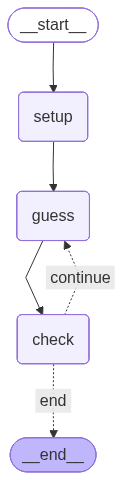

In [14]:
Image(app.get_graph().draw_mermaid_png())